<a href="https://colab.research.google.com/github/dionatrafk/model_evaluation/blob/master/MLP_exec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Multi Layer Perceptron (MLP)

**Execution options: **default 60 minute predictions.

**Copy a row of hyperparameters and paste into row 2 of the next cell.**



In [1]:
#definir hiperparâmetros
path = './http_requests_nasa/'
hyperparameters = [
('trace1.csv', 200, 130, 100, 10),
('trace5.csv', 110, 180, 50, 25),
('trace10.csv', 200, 130, 100, 10),
('trace15.csv', 130, 200, 60, 30),
('trace20.csv', 110, 190, 50, 16),
('trace25.csv', 130, 200, 60, 30),
('trace30.csv', 130, 200, 60, 30),
('trace35.csv', 130, 200, 60, 30),
('trace40.csv', 130, 200, 60, 30),
('trace45.csv', 130, 200, 60, 30),
('trace50.csv', 130, 200, 60, 30),
('trace55.csv', 130, 200, 30, 60),
('trace60.csv', 130, 130, 30, 30),
]

results = []

In [2]:
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import math

def create_dataset(dataset, lookback=1):
    dataX, dataY = [], [] # create 2 empty list

    # go through the lenght of dataset, subtract the lookback and 1. 
    #2 steps before the end of dataset, because we predict 1 step to the future
    for i in range(len(dataset)-lookback-1):
        a = dataset[i:(i+lookback),0]
        dataX.append(a)
        dataY.append(dataset[i+lookback,0]) # get the next value
    return np.array(dataX), np.array(dataY)

def save_model(model):
    filename = "data/" + "mlp" + ".h5"
    filename = "mlp" + ".h5"
    model.save(filename)

def mlp(filename, BATCH_SIZE, NB_EPOCHS, LAYER1, LAYER2):
    filename = path + filename  
    print(filename)
    #perc = float(sys.argv[6])
    np.random.seed(7)
    # Data preparation
    dataset = pd.read_csv(filename, usecols=[1], header=None)
    dataset = dataset.values #convert to the array
    dataset = dataset.astype('float32') # convert to float

    # length of our data set
    training_size = int(len(dataset)*0.67)
    testing_size = len(dataset)-training_size

    # split the data set
    train, test = dataset[0:training_size,:], dataset[training_size:len(dataset),:]
    #print(len(train),len(test))

    # one time step to the future
    lookback = 1
    trainX, trainY = create_dataset(train, lookback)
    testX, testY = create_dataset(test, lookback)

    #size = int(training_size * (perc /100))
    #trainX = trainX[0:training_size - size:]
    #strainY = trainY[0:training_size - size:]

    # create the model
    model_name = 'requests_MLP'
    model=Sequential()
    model.add(Dense(LAYER1, input_dim=lookback, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(LAYER2, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    #Compilation and training
    timer = datetime.datetime.now() 
    start = datetime.datetime.now()
    model.compile(loss = 'mean_squared_error', optimizer = "adam") 

    print("Compilation Time : ", datetime.datetime.now()  - start)
    start = datetime.datetime.now()

    model.fit(trainX,trainY,epochs=NB_EPOCHS, batch_size=BATCH_SIZE, verbose=0) 
    print("Training time : ", datetime.datetime.now()  - start)

    yhat = model.predict(trainX)
    y_train = trainY

    train_score = mean_squared_error(y_train, yhat)
    print ('Trainscore: %.2f MSE (%.2f RMSE)' %(train_score, math.sqrt(train_score)))
    start = datetime.datetime.now() 


    # Making predictions
    yhat = model.predict(testX)
    yhat = yhat.flatten()
    y_test = testY
    r2 = r2_score(y_test,yhat)

    print("test time: ",datetime.datetime.now()  - start)
    print("timer: ", datetime.datetime.now()  - timer)

    # configuration executed
    print('Filename:',filename)
    print('BATCH_SIZE:',BATCH_SIZE)
    print('NB_EPOCHS: ',NB_EPOCHS)
    print('LAYER1: ',LAYER1)
    print('LAYER2: ',LAYER2)

    print('R2: ',r2)
    test_score = mean_squared_error(y_test, yhat)
    rmse = math.sqrt(test_score)
    mae = mean_absolute_error(y_test, yhat)
    print ('Testscore %.2f' % rmse)
    print('MAE: %.2f' % mae)

    #plot executions
    plt.plot(yhat[-100:], label='Predicted')
    plt.plot(y_test[-100:], label='Current')
    plt.legend()
    plt.grid()

    plt.ylabel('Requests')
    plt.show()
    return {
        "dataset": filename,
        "batch_size": BATCH_SIZE,
        "epochs": NB_EPOCHS,
        "layer1": LAYER1,
        "layer2": LAYER2,
        "mae": mae,
        "mse": test_score,
        "rmse": rmse,
        "r2": r2,
    }

./http_requests_nasa/trace1.csv
Compilation Time :  0:00:00.002339


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:10.170721
828/828 ━━━━━━━━━━━━━━━━━━━━ 0s 208us/step
828/828 ━━━━━━━━━━━━━━━━━━━━ 0s 208us/step
Trainscore: 340.02 MSE (18.44 RMSE)
  1/408 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/stepTrainscore: 340.02 MSE (18.44 RMSE)
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 198us/step
408/408 ━━━━━━━━━━━━━━━━━━━━ 0s 198us/step
test time:  0:00:00.140290
timer:  0:00:10.603867
Filename: ./http_requests_nasa/trace1.csv
BATCH_SIZE: 200
NB_EPOCHS:  130
LAYER1:  100
LAYER2:  10
R2:  0.6330510973930359
Testscore 15.92
MAE: 12.11
test time:  0:00:00.140290
timer:  0:00:10.603867
Filename: ./http_requests_nasa/trace1.csv
BATCH_SIZE: 200
NB_EPOCHS:  130
LAYER1:  100
LAYER2:  10
R2:  0.6330510973930359
Testscore 15.92
MAE: 12.11


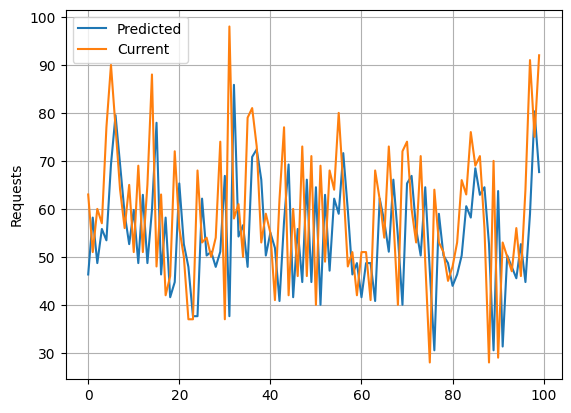

./http_requests_nasa/trace5.csv
Compilation Time :  0:00:00.000712
Compilation Time :  0:00:00.000712


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:06.025718
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 279us/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 279us/step
Trainscore: 4543.34 MSE (67.40 RMSE)
 1/82 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/stepTrainscore: 4543.34 MSE (67.40 RMSE)
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 264us/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 264us/step
test time:  0:00:00.050387
timer:  0:00:06.170063
Filename: ./http_requests_nasa/trace5.csv
BATCH_SIZE: 110
NB_EPOCHS:  180
LAYER1:  50
LAYER2:  25
R2:  0.7858761548995972
Testscore 54.74
MAE: 40.65
test time:  0:00:00.050387
timer:  0:00:06.170063
Filename: ./http_requests_nasa/trace5.csv
BATCH_SIZE: 110
NB_EPOCHS:  180
LAYER1:  50
LAYER2:  25
R2:  0.7858761548995972
Testscore 54.74
MAE: 40.65


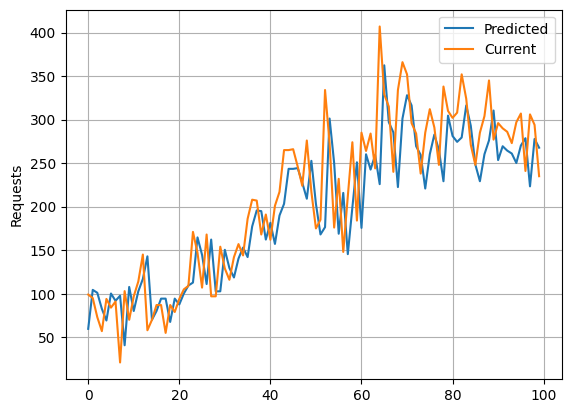

./http_requests_nasa/trace10.csv
Compilation Time :  0:00:00.000717


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:03.091426
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step
Trainscore: 12143.82 MSE (110.20 RMSE)
 1/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/stepTrainscore: 12143.82 MSE (110.20 RMSE)
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 359us/step
test time:  0:00:00.041112
timer:  0:00:03.206612
Filename: ./http_requests_nasa/trace10.csv
BATCH_SIZE: 200
NB_EPOCHS:  130
LAYER1:  100
LAYER2:  10
R2:  0.8327291011810303
Testscore 94.18
MAE: 70.37
test time:  0:00:00.041112
timer:  0:00:03.206612
Filename: ./http_requests_nasa/trace10.csv
BATCH_SIZE: 200
NB_EPOCHS:  130
LAYER1:  100
LAYER2:  10
R2:  0.8327291011810303
Testscore 94.18
MAE: 70.37


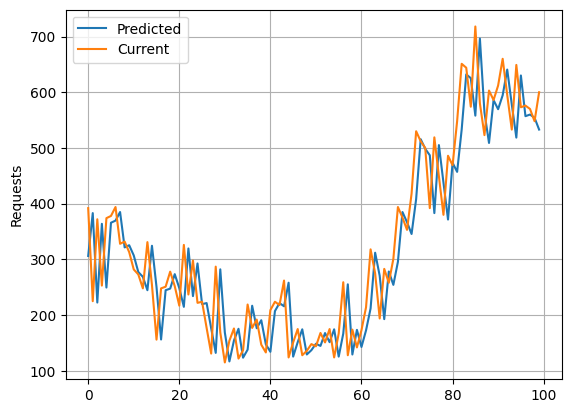

./http_requests_nasa/trace15.csv
Compilation Time :  0:00:00.000898


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:03.990851
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
Trainscore: 29175.67 MSE (170.81 RMSE)
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/stepTrainscore: 29175.67 MSE (170.81 RMSE)
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 410us/step
test time:  0:00:00.035150
timer:  0:00:04.092193
Filename: ./http_requests_nasa/trace15.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8191239833831787
Testscore 145.05
MAE: 107.53
test time:  0:00:00.035150
timer:  0:00:04.092193
Filename: ./http_requests_nasa/trace15.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8191239833831787
Testscore 145.05
MAE: 107.53


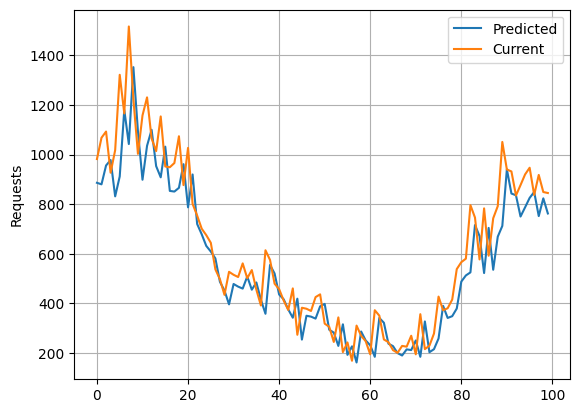

./http_requests_nasa/trace20.csv
Compilation Time :  0:00:00.000872


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:03.686852
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step
Trainscore: 40312.79 MSE (200.78 RMSE)
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step
Trainscore: 40312.79 MSE (200.78 RMSE)
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step
test time:  0:00:00.034742
timer:  0:00:03.782204
Filename: ./http_requests_nasa/trace20.csv
BATCH_SIZE: 110
NB_EPOCHS:  190
LAYER1:  50
LAYER2:  16
R2:  0.8390627503395081
Testscore 181.26
MAE: 136.79
test time:  0:00:00.034742
timer:  0:00:03.782204
Filename: ./http_requests_nasa/trace20.csv
BATCH_SIZE: 110
NB_EPOCHS:  190
LAYER1:  50
LAYER2:  16
R2:  0.8390627503395081
Testscore 181.26
MAE: 136.79


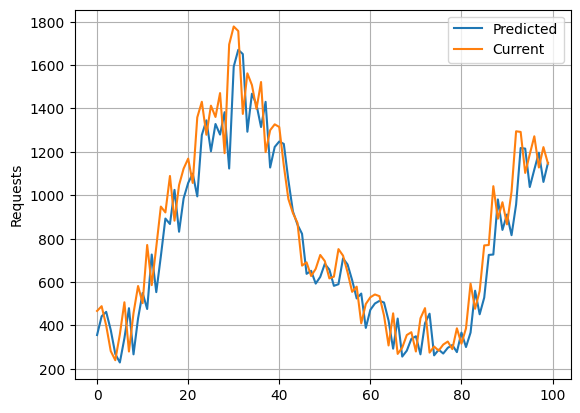

./http_requests_nasa/trace25.csv
Compilation Time :  0:00:00.000696


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:03.651379
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step
Trainscore: 58546.23 MSE (241.96 RMSE)
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step
Trainscore: 58546.23 MSE (241.96 RMSE)
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step
test time:  0:00:00.031121
timer:  0:00:03.739399
Filename: ./http_requests_nasa/trace25.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8705305457115173
Testscore 200.98
MAE: 151.48
test time:  0:00:00.031121
timer:  0:00:03.739399
Filename: ./http_requests_nasa/trace25.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8705305457115173
Testscore 200.98
MAE: 151.48


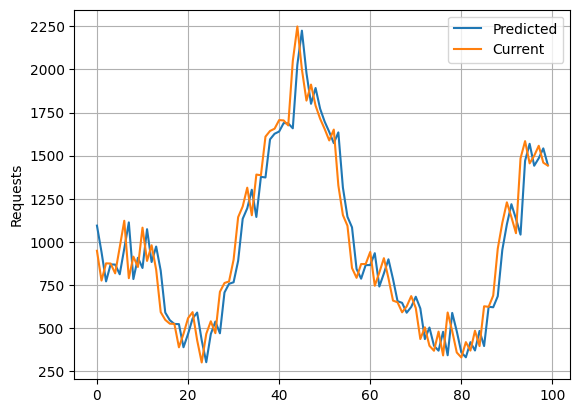

./http_requests_nasa/trace30.csv
Compilation Time :  0:00:00.000641


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:03.507843
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step
Trainscore: 81847.44 MSE (286.09 RMSE)
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step
Trainscore: 81847.44 MSE (286.09 RMSE)
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step
test time:  0:00:00.031193
timer:  0:00:03.595043
Filename: ./http_requests_nasa/trace30.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8616540431976318
Testscore 249.07
MAE: 180.92
test time:  0:00:00.031193
timer:  0:00:03.595043
Filename: ./http_requests_nasa/trace30.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8616540431976318
Testscore 249.07
MAE: 180.92


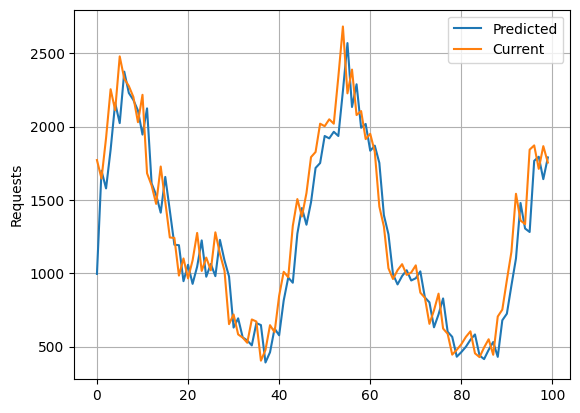

./http_requests_nasa/trace35.csv
Compilation Time :  0:00:00.000632


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:03.581875
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Trainscore: 121114.42 MSE (348.01 RMSE)
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step
Trainscore: 121114.42 MSE (348.01 RMSE)
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step
test time:  0:00:00.037647
timer:  0:00:03.684889
Filename: ./http_requests_nasa/trace35.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.871264636516571
Testscore 278.48
MAE: 207.98
test time:  0:00:00.037647
timer:  0:00:03.684889
Filename: ./http_requests_nasa/trace35.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.871264636516571
Testscore 278.48
MAE: 207.98


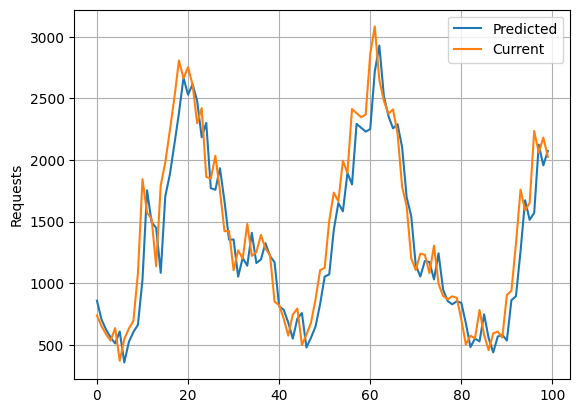

./http_requests_nasa/trace40.csv
Compilation Time :  0:00:00.000664


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:03.423146
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Trainscore: 187305.98 MSE (432.79 RMSE)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step
Trainscore: 187305.98 MSE (432.79 RMSE)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step
test time:  0:00:00.031892
timer:  0:00:03.515564
Filename: ./http_requests_nasa/trace40.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8419198393821716
Testscore 352.47
MAE: 262.19
test time:  0:00:00.031892
timer:  0:00:03.515564
Filename: ./http_requests_nasa/trace40.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8419198393821716
Testscore 352.47
MAE: 262.19


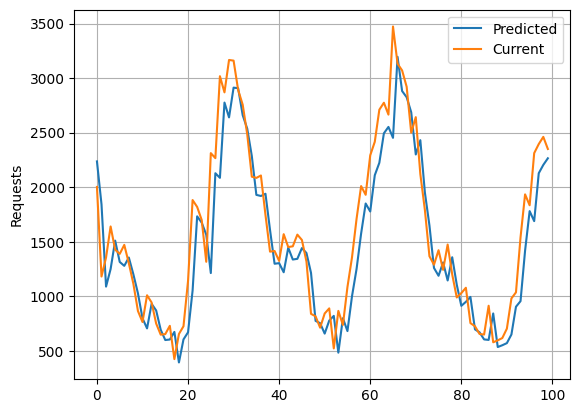

./http_requests_nasa/trace45.csv
Compilation Time :  0:00:00.000987


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:03.393802
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Trainscore: 229740.02 MSE (479.31 RMSE)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step
Trainscore: 229740.02 MSE (479.31 RMSE)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step
test time:  0:00:00.025406
timer:  0:00:03.471528
Filename: ./http_requests_nasa/trace45.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8450619578361511
Testscore 390.91
MAE: 290.36
test time:  0:00:00.025406
timer:  0:00:03.471528
Filename: ./http_requests_nasa/trace45.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8450619578361511
Testscore 390.91
MAE: 290.36


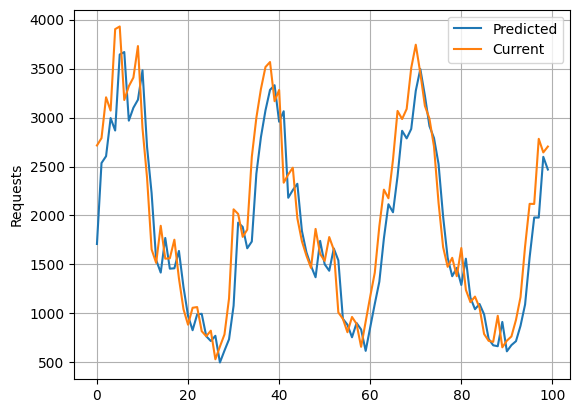

./http_requests_nasa/trace50.csv
Compilation Time :  0:00:00.000635


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:03.389079
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Trainscore: 358438.31 MSE (598.70 RMSE)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step
Trainscore: 358438.31 MSE (598.70 RMSE)
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step
test time:  0:00:00.028833
timer:  0:00:03.469527
Filename: ./http_requests_nasa/trace50.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8310498595237732
Testscore 451.24
MAE: 345.00
test time:  0:00:00.028833
timer:  0:00:03.469527
Filename: ./http_requests_nasa/trace50.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  60
LAYER2:  30
R2:  0.8310498595237732
Testscore 451.24
MAE: 345.00


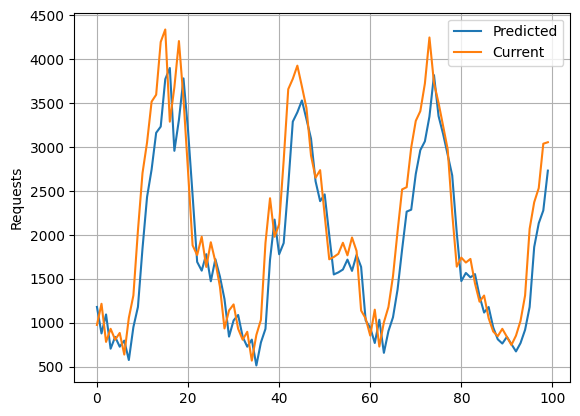

./http_requests_nasa/trace55.csv
Compilation Time :  0:00:00.000899


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:03.332796
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Trainscore: 733418.88 MSE (856.40 RMSE)
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Trainscore: 733418.88 MSE (856.40 RMSE)
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
test time:  0:00:00.059491
timer:  0:00:03.443395
Filename: ./http_requests_nasa/trace55.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  30
LAYER2:  60
R2:  0.7074115872383118
Testscore 653.30
MAE: 491.57
test time:  0:00:00.059491
timer:  0:00:03.443395
Filename: ./http_requests_nasa/trace55.csv
BATCH_SIZE: 130
NB_EPOCHS:  200
LAYER1:  30
LAYER2:  60
R2:  0.7074115872383118
Testscore 653.30
MAE: 491.57


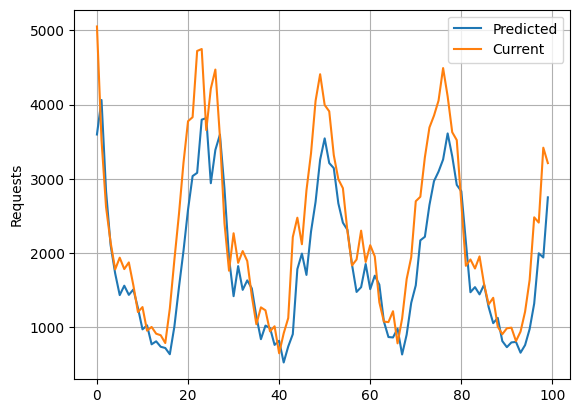

./http_requests_nasa/trace60.csv
Compilation Time :  0:00:00.000664


/Users/gabriel.herter/Documents/Personal/faculdade/prtica_em_pesquisa/model_evaluation/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training time :  0:00:02.304465
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Trainscore: 540734.88 MSE (735.35 RMSE)
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Trainscore: 540734.88 MSE (735.35 RMSE)
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
test time:  0:00:00.039021
timer:  0:00:02.393203
Filename: ./http_requests_nasa/trace60.csv
BATCH_SIZE: 130
NB_EPOCHS:  130
LAYER1:  30
LAYER2:  30
R2:  0.8196060061454773
Testscore 560.35
MAE: 425.52
test time:  0:00:00.039021
timer:  0:00:02.393203
Filename: ./http_requests_nasa/trace60.csv
BATCH_SIZE: 130
NB_EPOCHS:  130
LAYER1:  30
LAYER2:  30
R2:  0.8196060061454773
Testscore 560.35
MAE: 425.52


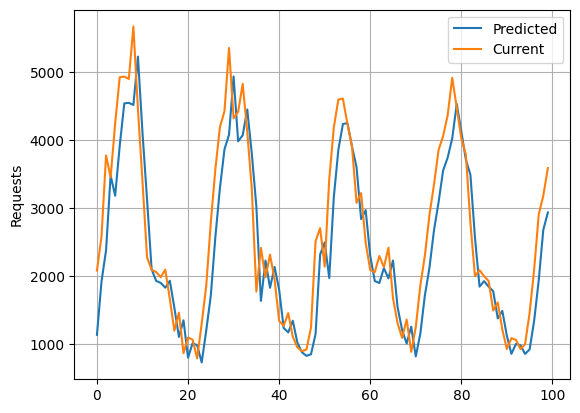

,dataset,batch_size,epochs,layer1,layer2,mae,mse,rmse,r2
0,./http_requests_nasa/trace1.csv,200,130,100,10,12.113,253.592,15.925,0.6331
1,./http_requests_nasa/trace5.csv,110,180,50,25,40.645,2996.308,54.739,0.7859
2,./http_requests_nasa/trace10.csv,200,130,100,10,70.374,8870.579,94.184,0.8327
3,./http_requests_nasa/trace15.csv,130,200,60,30,107.534,21038.873,145.048,0.8191
4,./http_requests_nasa/trace20.csv,110,190,50,16,136.787,32855.055,181.260,0.8391
5,./http_requests_nasa/trace25.csv,130,200,60,30,151.479,40391.922,200.977,0.8705
6,./http_requests_nasa/trace30.csv,130,200,60,30,180.922,62036.934,249.072,0.8617
7,./http_requests_nasa/trace35.csv,130,200,60,30,207.978,77552.109,278.482,0.8713
8,./http_requests_nasa/trace40.csv,130,200,60,30,262.190,124234.117,352.469,0.8419
9,./http_requests_nasa/trace45.csv,130,200,60,30,290.361,152813.672,390.914,0.8451


In [3]:
import pandas as pd

results = []
for params in hyperparameters:
    filename, BATCH_SIZE, NB_EPOCHS, LAYER1, LAYER2 = params
    result = mlp(filename, BATCH_SIZE, NB_EPOCHS, LAYER1, LAYER2)
    results.append(result)

if results:
    summary_df = pd.DataFrame(results)
    summary_df = summary_df[["dataset", "batch_size", "epochs", "layer1", "layer2", "mae", "mse", "rmse", "r2"]]
    display(summary_df.round({"mae": 3, "mse": 3, "rmse": 3, "r2": 4}))